In [18]:
import torch
from LSTM import LSTM
from GRU import GRU, expGRU
import matplotlib.pyplot as plt

# EXPONENTIAL DECAY

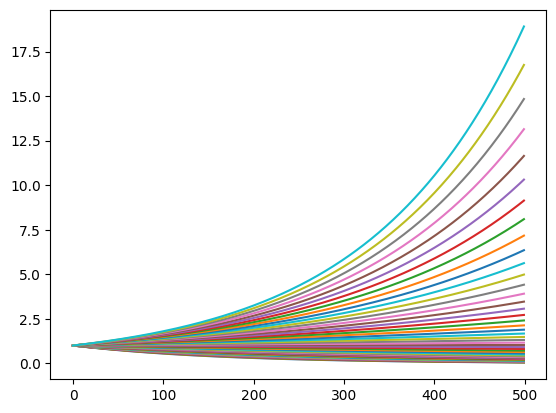

In [19]:
domain = torch.linspace(0, 1, 500)
exponents = torch.linspace(-3., 3, 100)
full_data = torch.exp(exponents[:, None] * domain[None, :])
train_data = full_data[::2]
test_data = full_data[1::2]
train_data.shape, test_data.shape
plt.plot(train_data.T)

In [20]:
lstm = LSTM(in_dim=1, output_size=1, latent_size=128)
gru = GRU(in_dim=1, output_size=1, latent_size=128)
expgru = expGRU(in_dim=1, output_size=1, latent_size=128)

In [21]:
lstm_optim = torch.optim.AdamW(lstm.parameters(), lr=1e-4, weight_decay=5e-2)
gru_optim = torch.optim.AdamW(gru.parameters(), lr=1e-4, weight_decay=5e-2)
expgru_optim = torch.optim.AdamW(expgru.parameters(), lr=1e-4, weight_decay=5e-2)

In [22]:
def train(model, optim, num_epochs, data, loss_fn=torch.nn.MSELoss()):
    for epoch in range(num_epochs):
        if epoch % 10 == 1:
            print(epoch, loss.item())
        optim.zero_grad()
        #Seems like an issue I had was I was feeding the data incorrectly. The network was predicting x from x, not x_t+1 from x_t
        y, *_ = model(data[:, :-1, :])
        loss = loss_fn(y, data[:, 1:, :])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optim.step()
    print(epoch, loss.item())

In [33]:
train(lstm, lstm_optim, 100, train_data.unsqueeze(-1))
train(gru, gru_optim, 100, train_data.unsqueeze(-1))
train(expgru, expgru_optim, 100, train_data.unsqueeze(-1))

1 0.0162576362490654
11 0.009850931353867054
21 0.01894829049706459
31 0.0017126328311860561
41 0.002382496139034629
51 0.0016625489806756377
61 0.0020010340958833694
71 0.0002308344846824184
81 0.0007335302652791142
91 0.0016979085048660636
99 0.0004476618196349591
1 1.7208213806152344
11 0.054848071187734604
21 0.0912070944905281
31 0.012278233654797077
41 0.0045922077260911465
51 0.017002899199724197
61 0.006354272365570068
71 0.004141463898122311
81 0.001401822199113667
91 0.001578300492838025
99 0.0024020615965127945
1 2.226384162902832
11 0.28514984250068665
21 0.1106201633810997
31 0.04366200789809227
41 0.03662586957216263
51 0.01560905296355486
61 0.01044204831123352
71 0.019619088619947433
81 0.042592331767082214
91 0.009933199733495712
99 0.006670357193797827


In [52]:
def generate_autoregressive(model, test_data, sequence_length, prime_len = 100):
    """
    Generates sequences by feeding the model's own output back to it.

    Args:
        model: The trained LSTM or GRU model.
        test_data: A batch of test sequences (e.g., test_data[:3]).
        sequence_length: The total length of the sequence to generate.
    """
    model.eval()  # Set the model to evaluation mode

    # Use the first time step of the test data as the starting point
    # Shape: [batch_size, 1, input_dim]
    current_input = test_data[:, 0:prime_len, :]
    batch_size = test_data.shape[0]

    # Initialize hidden and cell states
    if isinstance(model, LSTM):
       current_input, hidden_state, cell_state = model(current_input)
    else:
        current_input, hidden_state = model(current_input)

    generated_sequence = [current_input]
    current_input = current_input[:,-1:,:]
    with torch.no_grad():
        for _ in range(sequence_length - prime_len):
            # The model's forward pass takes a sequence of length 1
            if isinstance(model, LSTM):
                output, hidden_state, cell_state = model(current_input, hidden_state, cell_state)
            else: # GRU or expGRU
                output, hidden_state = model(current_input, hidden_state)

            # Store the prediction
            generated_sequence.append(output)

            # The output becomes the next input
            current_input = output

    return torch.cat(generated_sequence, dim=1)

Text(0.5, 0.98, 'Autoregression')

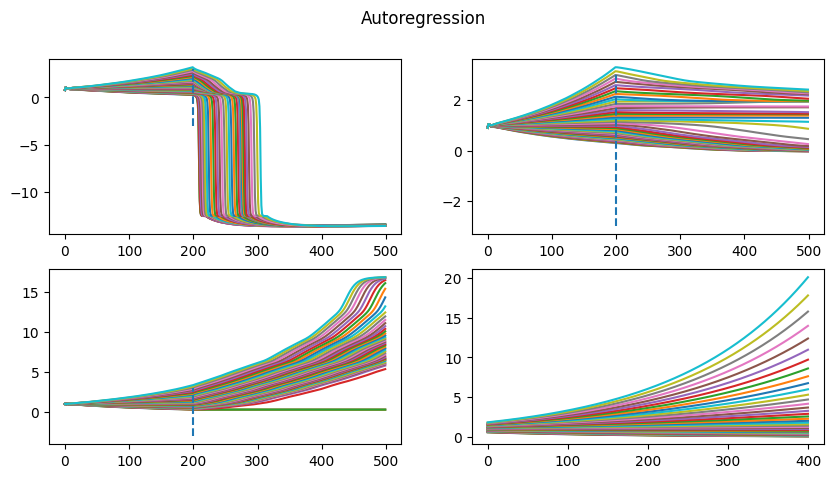

In [56]:
validation_data = test_data
fig, axs = plt.subplots(2,2, figsize=(10,5))
axs = axs.flatten()
plen = 200
for model, ax in zip([expgru, lstm, gru], axs):
    y = generate_autoregressive(model, validation_data.unsqueeze(-1), 500, prime_len=plen)
    ax.plot(y.detach().numpy().squeeze().T)
    ax.vlines(plen,ymin=-3,ymax=3, linestyles="dashed")
axs[3].plot(validation_data.T[99:])
fig.suptitle("Autoregression")

Text(0.5, 0.98, 'Full Data')

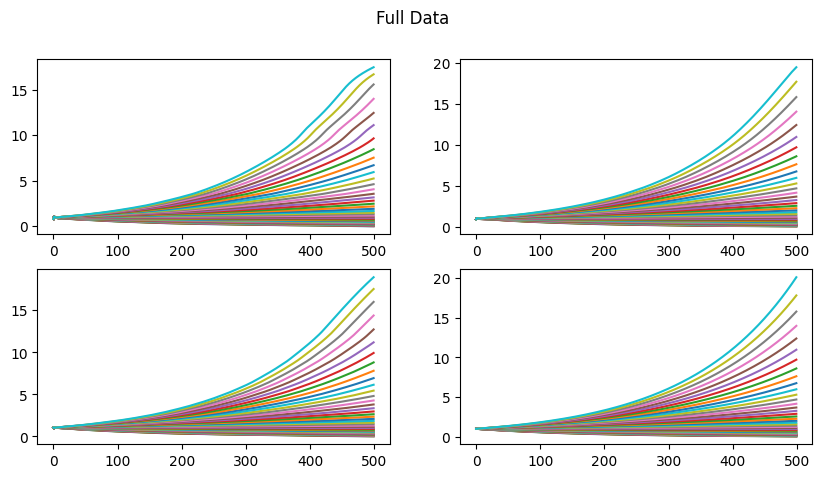

In [46]:
validation_data = test_data
fig, axs = plt.subplots(2,2, figsize=(10,5))
axs = axs.flatten()
for model, ax in zip([expgru, lstm, gru], axs):
    y, *_ = model(validation_data.unsqueeze(-1))
    ax.plot(y.detach().numpy().squeeze().T)
axs[3].plot(validation_data.T)
fig.suptitle("Full Data")

# Memory Test

In [82]:
# This is like the previous memory test, but harder: Now the number sequences can be of a varying length, and the empty space can vary as well. Adding a special "*" character to signify "message has ended"
code_alphabet = {0: "0", 1: "1", 2: "2", 3: "3", 4: "4", 5: "5", 6: "6", 7: "7", 8: "8", 9: "9", 10: "-", 11: ":", 12: "*"}
num_messages = 1000
code_lengths = torch.randint(3, 6, (num_messages,))
empty_lengths = torch.randint(5, 10, (num_messages,))
goal_length = 20
torch.manual_seed(0)
one_hots = torch.eye(13)
messages = []
responses = []
targets = []
#BUILDS THE MESSAGE
for code_length, empty_length in zip(code_lengths, empty_lengths):
    message_length = code_length * 2 + empty_length
    code = one_hots[torch.randint(0, 10, (code_length,))]  #Code is a sequence of random integers from 0-9
    empty = one_hots[torch.full((empty_length,), 10)]  #Empty space is a sequence of "-" characters
    code_space = one_hots[torch.full((code_length - 1,), 10)] #Extra "-" characters representing the code space
    start = one_hots[torch.full((1,), 11)] #Start symbol for the code
    message_ended = one_hots[torch.full((goal_length - message_length,), 12)] #MESSAGE ENDED sequence
    #print(code.shape, empty.shape, start.shape, code_space.shape, message_ended.shape)
    message = torch.cat([code, empty, start, code_space, message_ended], dim=0)
    #BUILDS THE RESPONSE
    pre_message = one_hots[torch.full((code_length + empty_length,), 10)]
    response = torch.cat([pre_message, code, message_ended], dim=0)
    target = response.argmax(dim=-1)

    messages.append(message)
    responses.append(response)
    targets.append(target)
messages = torch.stack(messages, dim=0)
responses = torch.stack(responses, dim=0)
targets = torch.stack(targets, dim=0)

In [103]:
cats = messages.argmax(dim=-1)
for element in targets:
    res = ""
    for elem in element:
        res += code_alphabet[elem.item()]
    print(res)

-------------4930***
--------397*********
-------------3731***
-----------6698*****
-----------6684*****
------------369*****
----------14419*****
----------99012*****
----------305*******
----------529*******
----------1883******
-------------69173**
------------521*****
---------093********
--------------11036*
---------679********
-----------63450****
------------82827***
-------------50081**
-------------96102**
-----------94393****
-------------93985**
----------3285******
--------------66572*
--------566*********
--------540*********
------------8178****
---------544********
-------------84490**
------------745*****
------------3373****
-----------099******
-------------3181***
------------78410***
-----------40497****
----------0014******
------------99592***
---------221********
------------4911****
----------0306******
------------7691****
-----------64105****
----------2581******
-------------8128***
-------------03892**
-------------7088***
-----------6858*****
------------6

In [92]:
def train_mem(model, optim, n_epochs):
    for epoch in range(n_epochs):
        if epoch % 10 == 1:
            print(epoch, loss.item())
        model.zero_grad()
        #Seems like an issue I had was I was feeding the data incorrectly. The network was predicting x from x, not x_t+1 from x_t
        y, *_ = model(messages)
        loss = torch.nn.CrossEntropyLoss()(y.view(-1, 13), targets.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optim.step()
    print(epoch, loss.item())

In [85]:
mem_lstm = LSTM(in_dim=13, output_size=13, latent_size=128)
mem_gru = GRU(in_dim=13, output_size=13, latent_size=128)
mem_expgru = expGRU(in_dim=13, output_size=13, latent_size=128)

In [109]:
mlstm_optim = torch.optim.AdamW(mem_lstm.parameters(), lr=1e-3)
mgru_optim = torch.optim.AdamW(mem_gru.parameters(), lr=1e-3)
mexpgru_optim = torch.optim.AdamW(mem_expgru.parameters(), lr=1e-3)

In [110]:
train_mem(mem_lstm, mlstm_optim, 100)
train_mem(mem_gru, mgru_optim, 100)
train_mem(mem_expgru, mexpgru_optim, 100)

1 0.09427745640277863
11 0.1191813126206398
21 0.09557206928730011
31 0.08548635989427567
41 0.07815423607826233
51 0.07219429314136505
61 0.06693766266107559
71 0.06232932582497597
81 0.05769336596131325
91 0.05346014350652695
99 0.04982514679431915
1 0.10937448590993881
11 0.13415215909481049
21 0.10992701351642609
31 0.09673368185758591
41 0.08697257936000824
51 0.07914253324270248
61 0.07231303304433823
71 0.07770746201276779
81 0.06642940640449524
91 0.05941306799650192
99 0.05451785773038864
1 0.18023152649402618
11 0.2533991038799286
21 0.20630747079849243
31 0.178199902176857
41 0.1605437695980072
51 0.14923572540283203
61 0.135313481092453
71 0.12490104883909225
81 0.1178453266620636
91 0.10979373753070831
99 0.10606247186660767


In [111]:
def print_responses(model):
    res, *_ = model(messages)
    idxs = res.argmax(dim=-1)
    for i, idx in enumerate(idxs):
        res = ""
        resp = ""
        for j in range(len(idx)):
            res += code_alphabet[idx[j].item()]
            resp += code_alphabet[responses[i][j].argmax().item()]
        print(res, "\n" +  resp)

In [114]:
print_responses(mem_expgru)

-------------4930*** 
-------------4930***
--------337********* 
--------397*********
-------------3331*** 
-------------3731***
-----------6698***** 
-----------6698*****
-----------6684***** 
-----------6684*****
------------369***** 
------------369*****
----------11119***** 
----------14419*****
----------99012***** 
----------99012*****
----------305******* 
----------305*******
----------529******* 
----------529*******
----------1883****** 
----------1883******
-------------69133** 
-------------69173**
------------521***** 
------------521*****
---------093******** 
---------093********
--------------11066* 
--------------11036*
---------679******** 
---------679********
-----------63450**** 
-----------63450****
------------88227*** 
------------82827***
-------------00081** 
-------------50081**
-------------91102** 
-------------96102**
-----------99933**** 
-----------94393****
-------------99985** 
-------------93985**
----------3285****** 
----------3285******
-----------